In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [33]:
df = pd.read_csv('Task 3 and 4_Loan_Data.csv', index_col = 0)

In [34]:
n_buckets = 10
min_bin_size = 50 #minimum in each bucket to avoid overfitting
laplace_alpha = 1.0 #additive smoothing

In [35]:
#aggregrate count per unique FICO score
aggr = df.groupby('fico_score')['default'].agg(['count','sum'])
fico_vals = aggr.index.values.astype(int)
counts = aggr['count'].values.astype(int)
defaults = aggr['sum'].values.astype(int)
m = len(fico_vals)
print(f'There are {m} unique values')

There are 374 unique values


In [36]:
#for our dynamic programming approach we will calculate the prefix sums, and then write a function to get inclusive stats
pref_n = np.concatenate(([0], np.cumsum(counts)))
pref_k = np.concatenate(([0], np.cumsum(defaults)))

def interval_stats(i, j):
    if j < i:
        return 0,0
    n = pref_n[j+1] - pref_n[i]
    k = pref_k[j+1] - pref_k[i]
    return int(n), int(k)


In [37]:
#we now score each interval using this function, and calculate a scoring matrix
def score_interval(i, j, alpha = laplace_alpha, min_size = min_bin_size):
    n, k = interval_stats(i, j)
    if n < min_size or n == 0:
        return -np.inf
    p = (k + alpha) / (n + 2.0 * alpha)
    p = np.clip(p, 1e-12, 1- 1e-12)
    return k * np.log(p) + (n-k) * np.log(1-p)

score_mat = np.full((m,m), -np.inf)
for i in range(m):
    for j in range(i,m):
        score_mat[i,j] = score_interval(i,j)

In [38]:
# Dynamic Programming
# dp[b, i] = best total score using (b+1) buckets that cover indices 0..i
# backptr[b, i] = j index where previous partition ended (so new bucket is j+1..i)

# Initialization: dp[0, i] = score_mat[0, i]
# Recurrence: dp[b, i] = max_{j in [b-1..i-1]} dp[b-1, j] + score_mat[j+1, i]

In [39]:
B = n_buckets
dp = np.full((B, m), -np.inf)
backptr = np.full((B, m), -1, dtype=int)


# base (1 bucket)
for i in range(m):
    dp[0, i] = score_mat[0, i]
    backptr[0, i] = -1


# fill DP
for b in range(1, B):
    for i in range(b, m):
        best_val = -np.inf
        best_j = -1
        # try all split points
        for j in range(b-1, i):
            if dp[b-1, j] == -np.inf:
                continue
            sc = score_mat[j+1, i]
            if sc == -np.inf:
                continue
            val = dp[b-1, j] + sc
            if val > best_val:
                best_val = val
                best_j = j
        dp[b, i] = best_val
        backptr[b, i] = best_j

print('DP solved. Best objective:', dp[B-1, m-1])

DP solved. Best objective: -4219.099842123667


In [40]:
boundaries_idx = []
cur_b = B - 1
cur_i = m - 1
while cur_b >= 0:
    j = backptr[cur_b, cur_i]
    start_idx = 0 if j == -1 else j + 1
    boundaries_idx.append((start_idx, cur_i))
    cur_i = j
    cur_b -= 1


boundaries_idx = boundaries_idx[::-1]


# build bucket records
buckets = []
for (i_start, i_end) in boundaries_idx:
    n, k = interval_stats(i_start, i_end)
    p = (k + laplace_alpha) / (n + 2.0 * laplace_alpha)
    bucket = {
        'min_fico': int(fico_vals[i_start]),
        'max_fico': int(fico_vals[i_end]),
        'n': n,
        'k': k,
        'p': float(p),
        'll': float(score_mat[i_start, i_end])
    }
    buckets.append(bucket)


print('Buckets reconstructed:')
for i, b in enumerate(buckets, 1):
    print(f"Bucket {i}: {b}")

Buckets reconstructed:
Bucket 1: {'min_fico': 408, 'max_fico': 502, 'n': 168, 'k': 121, 'p': 0.7176470588235294, 'll': -99.58114349904906}
Bucket 2: {'min_fico': 503, 'max_fico': 520, 'n': 133, 'k': 78, 'p': 0.5851851851851851, 'll': -90.19027004945022}
Bucket 3: {'min_fico': 521, 'max_fico': 552, 'n': 496, 'k': 229, 'p': 0.46184738955823296, 'll': -342.3439526644174}
Bucket 4: {'min_fico': 553, 'max_fico': 580, 'n': 911, 'k': 307, 'p': 0.3373493975903614, 'll': -582.1477651985007}
Bucket 5: {'min_fico': 581, 'max_fico': 611, 'n': 1561, 'k': 381, 'p': 0.24440179142674345, 'll': -867.4965027959323}
Bucket 6: {'min_fico': 612, 'max_fico': 649, 'n': 2465, 'k': 402, 'p': 0.16335630320226996, 'll': -1096.3027351634996}
Bucket 7: {'min_fico': 650, 'max_fico': 696, 'n': 2609, 'k': 256, 'p': 0.09842972041363462, 'll': -837.3250577618685}
Bucket 8: {'min_fico': 697, 'max_fico': 732, 'n': 1104, 'k': 64, 'p': 0.05877034358047016, 'll': -244.37438438594884}
Bucket 9: {'min_fico': 733, 'max_fico': 

             fico_score  fico_rating
customer_id                         
8153374             605            6
7442532             572            7
2256073             602            6
4885975             612            5
4700614             631            5


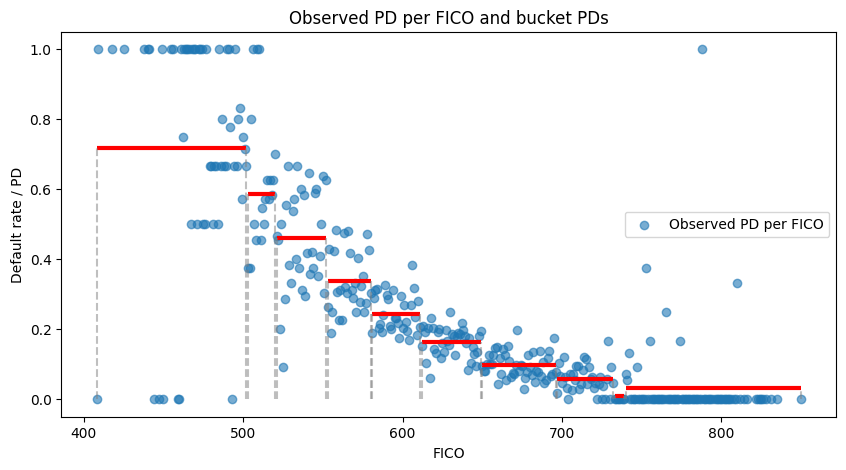

In [41]:
rating_map = {}
# buckets are ordered low-to-high FICO; we want rating 1 = highest FICO
for rating_idx, bucket in enumerate(reversed(buckets), start=1):
    for f in range(bucket['min_fico'], bucket['max_fico'] + 1):
        rating_map[f] = rating_idx


# helper to map new fico (float allowed) to rating


def map_fico_to_rating(fico, rating_map_local, buckets_local):
    """Map a continuous fico to a rating: find the bucket that contains the fico.
    If fico outside observed range, assign nearest bucket's rating.
    """
    fio = int(round(fico))
    if fio in rating_map_local:
        return rating_map_local[fio]
    # outside observed int range -> find nearest bucket by distance
    if fio < buckets_local[0]['min_fico']:
        return rating_map_local[buckets_local[-1]['min_fico']] # best bucket? careful with inversion
    if fio > buckets_local[-1]['max_fico']:
        return rating_map_local[buckets_local[0]['max_fico']]
    # else: search bucket by numeric range
    for rating_idx, bucket in enumerate(reversed(buckets_local), start=1):
        if bucket['min_fico'] <= fio <= bucket['max_fico']:
            return rating_idx
    # fallback
    return max(rating_map_local.values())


# %% [markdown]
# Attach rating to original df (for integer fico values this is direct; for floats use mapping helper)


# %%
if df['fico_score'].dtype.kind in 'fi':
# round/convert to int for mapping
    df['fico_int'] = df['fico_score'].round().astype(int)
    df['fico_rating'] = df['fico_int'].map(rating_map).fillna(len(buckets)).astype(int)
else:
    df['fico_rating'] = df['fico_score'].map(rating_map).fillna(len(buckets)).astype(int)


print(df[['fico_score', 'fico_rating']].head())


# %% [markdown]
# Plot: raw PD by FICO (observed default rate) and bucket PDs


# %%
# observed per-FICO pd
obs_pd = (aggr['sum'] / aggr['count']).values
plt.figure(figsize=(10, 5))
plt.scatter(fico_vals, obs_pd, label='Observed PD per FICO', alpha=0.6)
# plot bucket PD as horizontal lines
for b in buckets:
    plt.hlines(b['p'], b['min_fico'], b['max_fico'], colors='red', linewidth=3)
    plt.vlines([b['min_fico'], b['max_fico']], ymin=0, ymax=b['p'], colors='gray', linestyles='dashed', alpha=0.5)
plt.xlabel('FICO')
plt.ylabel('Default rate / PD')
plt.title('Observed PD per FICO and bucket PDs')
plt.legend()
plt.show()